In [1]:
import numpy as np
import pandas as pd
import os
import xarray as xr
import datetime
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

coast = pd.read_csv('/wk2/yungyun/code_space/FCNV2_test/plot/coast.csv')

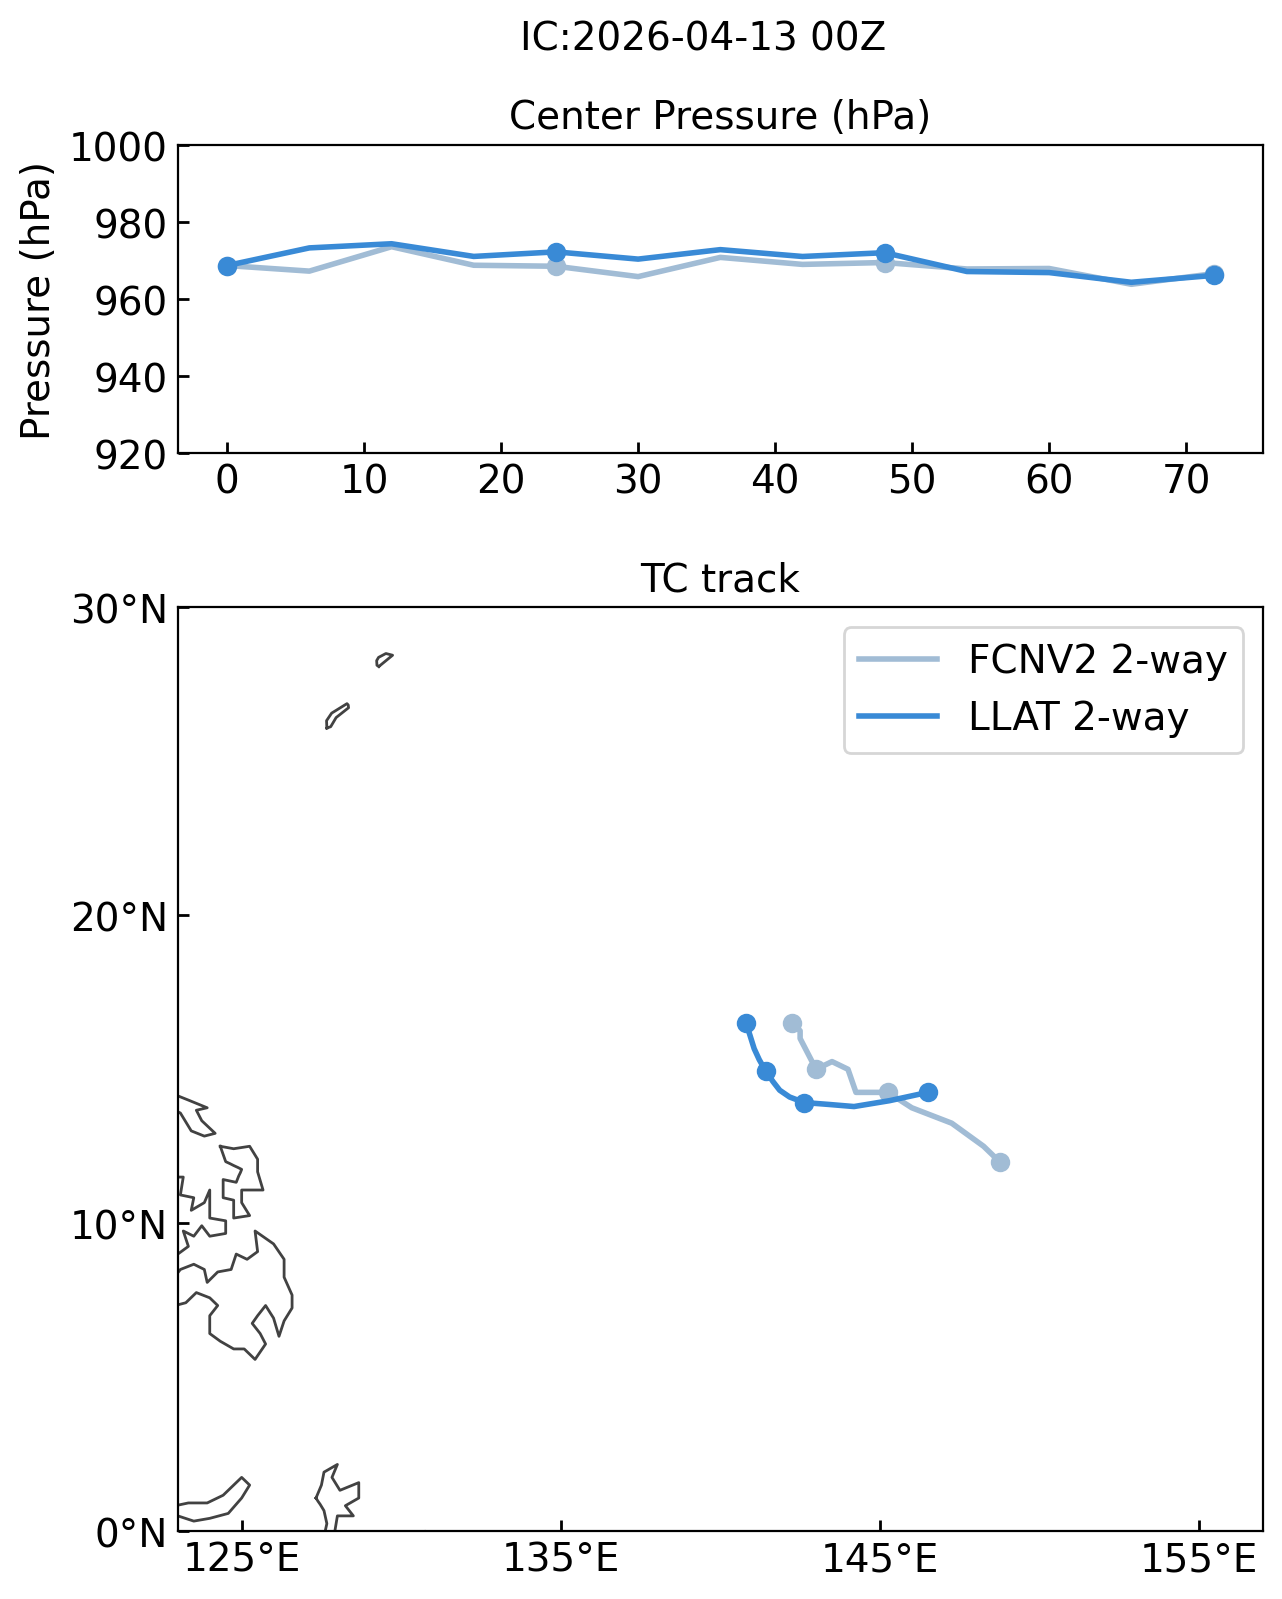

In [ ]:
from matplotlib.ticker import FuncFormatter

def lat_formatter(x, pos):
    return f"{abs(int(x))}°{'N' if x >= 0 else 'S'}"

def lon_formatter(x, pos):
    return f"{abs(int(x))}°{'E' if x >= 0 else 'W'}"

initial_time = datetime.datetime.strptime("2026041300", "%Y%m%d%H")
# ERA5_path = f'/wk2/yungyun/FCNV2_TC/{TC_ID}/ERA5'
# ERA5_truth = pd.read_csv(f'{ERA5_path}/ERA5_TC_track.csv')
# ERA5_truth = pd.read_csv(f'{ERA5_path}/ERA5_TC_track_new.csv')

# JMA_path = '/wk2/yungyun/ERA5_2024_for_TC/TC_list_JMA_v2/'
# JMA_TC_track = pd.read_csv(f'{JMA_path}/{TC_ID}.csv')
# JMA_TC_track['datetime'] = pd.to_datetime(JMA_TC_track[['Year', 'Month', 'Day', 'Hour']])
# JMA_after  = JMA_TC_track[JMA_TC_track["datetime"] >= initial_time].reset_index(drop=True)
# JMA_before = JMA_TC_track[JMA_TC_track["datetime"] <= initial_time].reset_index(drop=True)


exp_files = {
    # "LLAT ERA5": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/ERA5_bdy/start_from_{initial_time.strftime('%Y%m%d%H')}/DLAMPty_TC_track_radius5.csv",
    # "FCNV2 free": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{initial_time.strftime('%Y%m%d%H')}/FCNV2_TC_track_radius5.csv",
    # "FCNV2 free": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{initial_time.strftime('%Y%m%d%H')}/FCNV2_TC_track_radius3.csv",
    # "LLAT one-way": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{initial_time.strftime('%Y%m%d%H')}/DLAMPty_TC_track_radius5.csv",
    "FCNV2 2-way": f"../output_data/FCNV2_TC_track_radius5.csv",
    "LLAT 2-way": f"../output_data/LLAT_TC_track_radius5.csv",
    }

colors = {
    # "ERA5 bdy": '#FF5050',
    "LLAT ERA5": "#FE9292FF",
    "LLAT one-way": "#FC7805",
    "FCNV2 free": "#FFE600",
    "LLAT 2-way": "#398AD6",
    "FCNV2 2-way": "#A1BCD5",
}

# JMA_before = JMA_TC_track[JMA_TC_track["datetime"] <= initial_time].reset_index(drop=True)
# JMA_after  = JMA_TC_track[JMA_TC_track["datetime"] >= initial_time].reset_index(drop=True)

# ERA5_before = ERA5_truth[ERA5_truth["time"] <= int(initial_time.strftime("%Y%m%d%H"))].reset_index(drop=True)
# ERA5_before = ERA5_before[ERA5_before["time"] >= int(JMA_before["datetime"].iloc[0].strftime("%Y%m%d%H"))].reset_index(drop=True)
# ERA5_after  = ERA5_truth[ERA5_truth["time"] >= int(initial_time.strftime("%Y%m%d%H"))].reset_index(drop=True)
# ERA5_after  = ERA5_after[ERA5_after["time"] <= int(JMA_after["datetime"].iloc[-1].strftime("%Y%m%d%H"))].reset_index(drop=True)

# 建立畫布
fig = plt.figure(figsize=(7, 9),dpi=200)  # 可依比例調整大小

font = {'weight'     : 'normal',
        'size'       : 14
        }
axes = {'titlesize'  : 14,
        'titleweight': 'normal',
        'labelsize'  : 14,
        'labelweight': 'normal'
        }
mpl.rc('font', **font)  # pass in the font dict as kwargs
mpl.rc('axes', **axes)
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 3], hspace=0.25)  # 1:3 水平比例
ax1 = fig.add_subplot(gs[0])    
ax2 = fig.add_subplot(gs[1])

# 每條模型路徑畫一條線
for label, path in exp_files.items():
    exp_track = pd.read_csv(path)
    # exp_track.loc[0, "lon"] = JMA_after.loc[0, "Long."]
    # exp_track.loc[0, "lat"] = JMA_after.loc[0, "Lat."]
    # exp_track.loc[0, "Pressure (hPa)"]  = ERA5_after.loc[0, "Pressure (hPa)"] 
    # exp_track = exp_track[exp_track["time"]<=int(JMA_after["datetime"].iloc[-1].strftime("%Y%m%d%H"))].reset_index(drop=True)
    
    # time = np.arange(len(exp_track))*6+6*(len(JMA_before)-1)
    time = np.arange(len(exp_track))*6

    # 子圖 1（佔 1 單位寬度）
    ax1.plot(time, exp_track['Pressure (hPa)']/100, '-',color=colors[label], linewidth=2, label=label)
    ax1.plot(time[0::4], exp_track['Pressure (hPa)'].iloc[0::4]/100, 'o',color=colors[label], linewidth=2)


    # 子圖 2（佔 3 單位寬度）
    ax2.plot(exp_track['lon'], exp_track['lat'], '-',color=colors[label], linewidth=2, label=label)
    ax2.plot(exp_track['lon'].iloc[0::4], exp_track['lat'].iloc[0::4], 'o',color=colors[label], linewidth=2)

ax1.tick_params(direction='in', width=1, length=4)
ax2.tick_params(direction='in', width=1, length=4)
    
ax2.plot(coast.lon_map, coast.lat_map, color='#424242', linewidth=1.0)
# ax2.set_xlim([113, 147])
# ax2.set_ylim([10,40])
ax2.set_xlim([123, 157])
ax2.set_ylim([0,30])


ax1.set_title("Center Pressure (hPa)")
# JMA_time_list=np.arange(len(JMA_after))*6+6*(len(JMA_before)-1)
# ax1.plot(np.arange(len(JMA_before))*6, JMA_before['Pressure (hPa)'], '-',color='gray', linewidth=2)
# ax1.plot(JMA_time_list, JMA_after['Pressure (hPa)'], '-',color='k', linewidth=2, label='JMA')
# ax1.plot(JMA_time_list[0::4], JMA_after['Pressure (hPa)'][0::4], 'o',color='k', linewidth=2)

# ax1.plot(np.arange(len(ERA5_before))*6, ERA5_before['Pressure (hPa)']/100, '-',color="#ECA0F9FF", linewidth=1.6)
# ax1.plot(JMA_time_list, ERA5_after['Pressure (hPa)']/100, '-',color="#E220E5", linewidth=1.6, label='ER5 data')
# ax1.plot(JMA_time_list[0::4], ERA5_after['Pressure (hPa)'][0::4]/100, 'o',color='#E220E5', linewidth=2)

# labels = [(JMA_before['datetime'].iloc[0] +datetime.timedelta(hours=6*i)).strftime('%m/%d\n%H Z') for i in range(len(time) + int(len(JMA_before)-1))]

# past_time_mod = np.int_(np.mod(len(JMA_before)-1,4))
# ax1.set_xticks(np.arange(past_time_mod,len(labels),4)*6)
ax1.set_yticks(np.arange(920,1011,20))
# ax1.set_xticklabels(labels[past_time_mod::4])
# ax1.set_xlim([-1, len(JMA_TC_track)*6+1])

ax1.set_ylabel("Pressure (hPa)")
ax1.tick_params(axis='x', labelsize=14)

# ax1.set_xticks(np.arange(len(df_before.time)-1,len(ERA5_truth_track.time),4)*6)
# ax1.set_xticklabels(labels[len(df_before.time)-1::4])

ax2.set_title("TC track")    
# ax2.plot(ERA5_before.lon, ERA5_before.lat, '-',color='#E220E5', linewidth=2, label='ERA5 data')

# # ax2.plot(ERA5_before['lon'], ERA5_before['lat'], '-',color='gray', linewidth=2)
# ax2.plot(ERA5_after['msl_lon'], ERA5_after['msl_lat'], '-',color='#E220E5', linewidth=2.5, label='ERA5 data')
# ax2.plot(ERA5_after['msl_lon'].iloc[0::4], ERA5_after['msl_lat'].iloc[0::4], 'o',color='#E220E5', linewidth=2.5)

# ax2.plot(JMA_before['Long.'], JMA_before['Lat.'], '-',color='gray', linewidth=2)
# ax2.plot(JMA_after['Long.'], JMA_after['Lat.'], '-',color='k', linewidth=2, label='Best track')
# ax2.plot(JMA_after['Long.'].iloc[0::4], JMA_after['Lat.'].iloc[0::4], 'o',color='k', linewidth=2)


ax2.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
ax2.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
ax2.set_xticks(np.arange(125,156,10))
ax2.set_yticks(np.arange(0,31,10))
# ax2.set_xticks(np.arange(115,146,10))
# ax2.set_yticks(np.arange(10,41,10))

# ax2.set_xlabel("Longitude")
# ax2.set_ylabel("Latitude")
ax2.legend()
plt.suptitle(f'IC:{initial_time.strftime("%Y-%m-%d %H")}Z',y=0.95,fontsize=14)
plt.show()
# plt.savefig(f'/wk2/yungyun/FCNV2_TC/202421W/figure/{initial_time.strftime("%Y%m%d%H")}.png',dpi=200)
# plt.close()


In [9]:

import metpy.calc as mcalc
from metpy.units import units as munits
import multiprocessing as mp
from pysolar import solar, radiation
import xarray_regrid

core_count = mp.cpu_count() // 2
land_data = xr.open_dataset("/wk2/yungyun/code_space/couple_DWP_model/regional_model/DLAMPty/scripts_plot/utils/land.nc")

hourdelta_ndarray = np.vectorize(lambda x: datetime.timedelta(hours=int(x)))

sod_ndarray = np.vectorize(
    lambda dt_obj: dt_obj.hour * 3600 + dt_obj.minute * 60 + dt_obj.second
)

get_doy = lambda dt_obj: dt_obj.timetuple().tm_yday


doy_ndarray = np.vectorize(get_doy)


def get_max_doy(ds: xr.Dataset) -> int:
    """
    Get the maximum day of year (DOY) from an xarray dataset.
    """
    last_day = datetime.datetime(year=datetime_extractor(ds).year, month=12, day=31)
    return get_doy(last_day)

def cyclical_encoder(
    original: np.ndarray, max_val: float
) -> tuple[np.ndarray, np.ndarray]:
    """
    Encode a cyclical value (e.g. hour of day, day of year, etc.) into two components
    using a sine and cosine transformation.

    Parameters
    ----------
    original : np.ndarray
        The values to be encoded
    max_val : float
        The maximum possible value of the cyclical variable

    Returns
    -------
    tuple[np.ndarray,np.ndarray]
        Two arrays of the same shape as `original`, containing the sine and cosine
        components of the encoding.
    """
    sin_conponents = np.sin(2 * np.pi * original / max_val)
    cos_conponents = np.cos(2 * np.pi * original / max_val)

    return sin_conponents, cos_conponents

def localtime_grid_from_utc(ds: xr.Dataset) -> np.ndarray:
    time = datetime_extractor(ds)
    # convert the datetime object to local time according to the timezone of each grid cell in ds
    longitude = None
    if "time" in ds.keys():
        longitude = xr.broadcast(ds.time, ds.latitude, ds.longitude)[-1]
    else:
        longitude = xr.broadcast(ds.latitude, ds.longitude)[-1]

    z = hourdelta_ndarray(np.floor(longitude / 15).astype(int))
    return z + time

def datetime_extractor(ds: xr.Dataset) -> datetime:
    """
    Extract datetime information from an xarray dataset.
    """
    # # print(ds.time.values[0])  # like: 2008-01-12T12:00:00.000000000
    # # convert the time string to a datetime object
    # time_str = str(ds.time.values[0]).split(".")[0]
    # time_obj = datetime.strptime(time_str, "%Y-%m-%dT%H:%M:%S").replace(
    #     tzinfo=timezone.utc
    # )
    # return time_obj
    if "utc_time" in ds:
        return (
            ds.utc_time.values.astype("datetime64[s]")
            .astype(datetime)
            .replace(tzinfo=datetime.timezone.utc)
        )
    return (
        ds.time.values[0]
        .astype("datetime64[s]")
        .astype(datetime.datetime)
        .replace(tzinfo=datetime.timezone.utc)
    )


def get_radiation(date: datetime, lat: float, lon: float) -> float:
    """
    Calculate the amount of direct radiation at the given location and time.

    Parameters
    ----------
    date : datetime
        The time at which to calculate the radiation
    lat : float
        The latitude of the location
    lon : float
        The longitude of the location

    Returns
    -------
    radiation : float
        The amount of direct radiation at the given location and time
    """
    # get the solar altitude at the given location and time
    altitude = solar.get_altitude(lat, lon, date)
    # calculate the direct radiation at the given altitude
    radiation_direct = radiation.get_radiation_direct(date, altitude)
    # return the direct radiation
    return radiation_direct

def compute_chunk(args):
    lat_block, lon_block, utc_time = args
    # Vectorize the get_radiation function over the block.
    vectorized_rad = np.vectorize(lambda lat, lon: get_radiation(utc_time, lat, lon))
    return vectorized_rad(lat_block, lon_block)

def radiation_from_ds(ds: xr.Dataset, utc_time: datetime) -> xr.DataArray:
    # Use raw_lat and raw_lon if available; otherwise, broadcast.
    if "raw_lat" in ds.keys() and "raw_lon" in ds.keys():
        lat = ds["raw_lat"].data
        lon = ds["raw_lon"].data
    else:
        lat, lon = xr.broadcast(ds.latitude, ds.longitude)
        lat = lat.data
        lon = lon.data

    chunk_size = 3  # Adjust this size based on your data dimensions
    tasks = []
    positions = []
    nrows, ncols = lat.shape
    for i in range(0, nrows, chunk_size):
        for j in range(0, ncols, chunk_size):
            lat_block = lat[i : i + chunk_size, j : j + chunk_size]
            lon_block = lon[i : i + chunk_size, j : j + chunk_size]
            tasks.append((lat_block, lon_block, utc_time))
            positions.append((i, j))

    # Use half of cores for processing
    with mp.Pool(processes=core_count) as pool:
        results = pool.map(compute_chunk, tasks)

    # Reassemble the computed blocks into the full result array.
    result_array = np.empty(lat.shape)
    for (i, j), block in zip(positions, results):
        r, c = block.shape
        result_array[i : i + r, j : j + c] = block

    if 'time' in ds["u10"].dims:
        result_array = np.expand_dims(result_array, ds["u10"].dims.index('time'))

    # Return as an xarray DataArray with the same coordinates/dimensions as u10.
    return fillna_intp(
        xr.DataArray(result_array, coords=ds["u10"].coords, dims=ds["u10"].dims)
    )

def fillna_intp(da: xr.DataArray) -> xr.DataArray:
    if da.isnull().sum().values > 0:
        da = da.ffill(dim="latitude")
        if da.isnull().sum().values > 0:
            da = da.bfill(dim="latitude")
            if da.isnull().sum().values > 0:
                da = da.ffill(dim="longitude")
                if da.isnull().sum().values > 0:
                    da = da.bfill(dim="longitude")
                    if da.isnull().sum().values > 0:
                        da = da.ffill(dim="level")
                        if da.isnull().sum().values > 0:
                            da = da.bfill(dim="level")

    return da
def calc_additional_vars(ds: xr.Dataset, force: bool = False) -> xr.Dataset:
    if not "ws" in ds.keys():
        # if force or not "ws" in ds.keys():
        ds["ws"] = mcalc.wind_speed(ds.u, ds.v)
    if not "vort" in ds.keys():
        # if force or not "vort" in ds.keys():
        ds["vort"] = mcalc.vorticity(ds.u, ds.v)
    if not "theta_e" in ds.keys():
        # if force or not "theta_e" in ds.keys():
        # inflate ds.level to ds.pressure that match the shape of ds.q
        pressure = xr.broadcast(ds.level, ds.latitude, ds.longitude)[1] * munits.hPa
        if "time" in ds.keys():
            pressure = (
                xr.broadcast(ds.time, ds.level, ds.latitude, ds.longitude)[1]
                * munits.hPa
            )
        # pressure.assign_attrs["units"] = "hPa"
        ds["dewpoint"] = mcalc.dewpoint_from_specific_humidity(pressure, ds.q)
        ds["theta_e"] = mcalc.equivalent_potential_temperature(pressure, ds.t, ds.dewpoint)  # type: ignore
        ds["dewpoint"] = fillna_intp(ds["dewpoint"])
        ds["theta_e"] = fillna_intp(ds["theta_e"])
    if not "ws10" in ds.keys():
        # if force or not "ws10" in ds.keys():
        ds["ws10"] = mcalc.wind_speed(ds.u10, ds.v10)
    if not "vort10" in ds.keys():
        # if force or not "vort10" in ds.keys():
        ds["vort10"] = mcalc.vorticity(ds.u10, ds.v10)
    if force or not "f" in ds.keys():
        if "time" in ds.keys():
            ds["f"] = mcalc.coriolis_parameter(xr.broadcast(ds.time, ds.latitude, ds.longitude)[1])  # type: ignore
        else:
            lat = xr.broadcast(ds.streamplot_lat, ds.streamplot_lon)[0]
            ds["f"] = mcalc.coriolis_parameter(lat)  # type: ignore
            # ds["f"] = mcalc.coriolis_parameter(xr.broadcast(ds.latitude, ds.longitude)[0])  # type: ignore
        # elif "raw_lat" in ds.keys():
        #     ds["f"] = mcalc.coriolis_parameter(ds.raw_lat)  # type: ignore

    # fill missing values in ds sea surface temperature with t2m, as new variable
    if "sst" in ds.keys():
        if not "sst_filled_with_t2m" in ds.keys():
            ds["sst_filled_with_t2m"] = ds.sst.fillna(ds.t2m)
        if not "sst_filled" in ds.keys():
            ds["sst_filled"] = ds.sst.fillna(297.15)

    # add land data
    if force or not "landmask" in ds.keys():
        partial_land = land_data.regrid.linear(ds).broadcast_like(ds.u10)
        ds["hgt"] = partial_land.hgt
        ds["landmask"] = partial_land.landmask

    ds_with_time = "time" in ds.keys() or "utc_time" in ds.keys()
    if ds_with_time:
        if force or not "solar" in ds.keys():
            ds["solar"] = radiation_from_ds(ds, datetime_extractor(ds))

        if force or not "diurnal_sin" in ds.keys():
            localtime_grid = localtime_grid_from_utc(ds)
            coords = [ds.latitude, ds.longitude]
            dims = ["latitude", "longitude"]
            if "time" in ds.keys():
                coords = [ds.time, ds.latitude, ds.longitude]
                dims = ["time", "latitude", "longitude"]
            # add diurnal cycle variables
            # diurnal
            diurnal_sin, diurnal_cos = cyclical_encoder(
                sod_ndarray(localtime_grid), 86400
            )
            ds["diurnal_sin"] = xr.DataArray(
                diurnal_sin,
                coords=coords,
                dims=dims,
            )
            ds["diurnal_cos"] = xr.DataArray(
                diurnal_cos,
                coords=coords,
                dims=dims,
            )
            # day of year
            doy_sin, doy_cos = cyclical_encoder(
                doy_ndarray(localtime_grid), get_max_doy(ds)
            )
            ds["doy_sin"] = xr.DataArray(
                doy_sin,
                coords=coords,
                dims=dims,
            )
            ds["doy_cos"] = xr.DataArray(
                doy_cos,
                coords=coords,
                dims=dims,
            )

    return ds

def lonlat_uniformizer(
    raw_lon,
    raw_lat,
    uniformize_lonlat: bool = True,
    specify_resolution: bool | float | tuple[float, float] = False,
):
    """
    Generate longitude and latitude arrays for xarray DataArray.

    Parameters
    ----------
    raw_lon : np.ndarray
        A 2D array of longitude values.
    raw_lat : np.ndarray
        A 2D array of latitude values.
    uniformize_lonlat : bool, optional
        Whether to create uniform longitude and latitude arrays. Default is True.
    specify_resolution : bool | float | tuple[float, float], optional
        Option to specify the resolution of the longitude and latitude arrays.
        If a tuple, the first element is the resolution for longitude and
        the second for latitude. If a float, it applies to both.
        If False, resolution is not specified. Default is False.

    Returns
    -------
    lon : np.ndarray
        A 1D array of longi tude values.
    lat : np.ndarray
        A 1D array of latitude values.
    """
    # original lon and lat axis values
    lon = raw_lon.mean(0)
    lat = raw_lat.mean(1)

    if uniformize_lonlat:
        # calc the average of resolution of raw_lat
        # these step also make sure the direction of lat and lon is the same with the direction of raw_lat and raw_lon
        lat_diff = np.diff(raw_lat, axis=0).flatten()
        lat_res = lat_diff.mean()

        # calc the average of resolution of raw_lon
        lon_diff = np.diff(raw_lon, axis=1).flatten()
        lon_res = lon_diff.mean()

        if isinstance(specify_resolution, tuple):
            if specify_resolution[0] == 0:
                lon_res = 0
            elif specify_resolution[0] * lon_res > 0:
                lon_res = specify_resolution[0]
            else:
                lon_res = specify_resolution[0] * -1
            if specify_resolution[1] == 0:
                lat_res = 0
            elif specify_resolution[1] * lat_res > 0:
                lat_res = specify_resolution[1]
            else:
                lat_res = specify_resolution[1] * -1
        elif specify_resolution:
            if specify_resolution * lon_res >= 0:
                lon_res = specify_resolution
            else:
                lon_res = specify_resolution * -1
            if specify_resolution * lat_res >= 0:
                lat_res = specify_resolution
            else:
                lat_res = specify_resolution * -1
        else:
            vaild_lat_diff = lat_diff[
                (np.abs(lat_diff - np.mean(lat_diff)) < 2 * np.std(lat_diff))
            ]
            if len(vaild_lat_diff) > 0:
                lat_res = vaild_lat_diff.mean()
            vaild_lon_diff = lon_diff[
                (np.abs(lon_diff - np.mean(lon_diff)) < 2 * np.std(lon_diff))
            ]
            if len(vaild_lon_diff) > 0:
                lon_res = vaild_lon_diff.mean()
        # print(f"lat_res: {lat_res}")
        # print(f"lon_res: {lon_res}")

        # if the resolution is 0, set it to 0.25
        # if lat_res == 0:
        #     lat_res = 0.25
        # if lon_res == 0:
        #     lon_res = 0.25

        # locate the center
        lat_center = lat.mean()
        lon_center = lon.mean()
        # calc the length of lat and lon
        half_lat_length = np.floor(len(raw_lat[:, 0]) / 2)
        half_lon_length = np.floor(len(raw_lon[0, :]) / 2)
        # re-calculate the lon and lat arrays with the center value
        lat = np.linspace(
            lat_center - lat_res * half_lat_length,
            lat_center + lat_res * half_lat_length,
            len(lat),
        )
        lon = np.linspace(
            lon_center - lon_res * half_lon_length,
            lon_center + lon_res * half_lon_length,
            len(lon),
        )

    return lon, lat

def to_xarray(
    upper,
    sfc,
    upper_vars: list[str],
    surface_vars: list[str],
    upper_units: list[str],
    surface_units: list[str],
    pressure_levels: list[int],
    flip: bool = False,
    uniformize_lonlat: bool = False,
    specify_resolution: bool | float | tuple[float, float] = False,
    utc_time: datetime.datetime | None = None,
    force_additions: bool = False,
):
    """
    Convert the raw data to xarray dataset format.

    Parameters
    ----------
    upper : array_like
        The upper air variables, with shape (n_levels, n_lat, n_lon, n_vars).
    sfc : array_like
        The surface variables, with shape (n_lat, n_lon, n_vars).
    upper_vars : list[str]
        The names of the upper air variables.
    surface_vars : list[str]
        The names of the surface variables.
    upper_units : list[str]
        The units of the upper air variables.
    surface_units : list[str]
        The units of the surface variables.
    pressure_levels : list[int]
        The pressure levels of the upper air variables.
    flip : bool, optional
        Whether to flip the latitude array. Default is False.
    recreate_lonlat : bool, optional
        Whether to recreate the longitude and latitude arrays, or use the original ones. Default is False.
    specify_resolution : bool | float | tuple[float, float], optional
        Whether to specify the resolution of the longitude and latitude arrays. If False, the resolution will be calculated from the data. If float, the resolution will be set to the specified value. If tuple, the first element is the resolution of longitude and the second element is the resolution of latitude. Default is False.

    Returns
    -------
    xr.Dataset
        The xarray dataset containing the data.
    """
    if not isinstance(upper, np.ndarray):
        upper = upper.numpy()
    if not isinstance(sfc, np.ndarray):
        sfc = sfc.numpy()

    upper = np.squeeze(upper)
    sfc = np.squeeze(sfc)

    raw_lon = sfc[:, :, -2]
    raw_lat = sfc[:, :, -1]
    if flip:
        raw_lon = np.flipud(raw_lon)
        raw_lat = np.flipud(raw_lat)

    lon, lat = lonlat_uniformizer(
        raw_lon, raw_lat, uniformize_lonlat, specify_resolution
    )

    if uniformize_lonlat:
        streamplot_lat = lat
        streamplot_lon = lon

    else:
        # re-calculate the lon and lat arrays for streamplot only, to make sure they are equally spaced
        # otherwise, streamplot will not work
        streamplot_lat = raw_lat  # .mean(axis=1)
        streamplot_lon = raw_lon  # .mean(axis=0)

        max_lon = streamplot_lon.max()
        min_lon = streamplot_lon.min()
        max_lat = streamplot_lat.max()
        min_lat = streamplot_lat.min()

        if lon[0] > lon[-1]:
            streamplot_lon = np.linspace(max_lon, min_lon, len(lon))
        else:
            streamplot_lon = np.linspace(min_lon, max_lon, len(lon))
        if lat[0] > lat[-1]:
            streamplot_lat = np.linspace(max_lat, min_lat, len(lat))
        else:
            streamplot_lat = np.linspace(min_lat, max_lat, len(lat))

    data = dict()

    if utc_time is not None:
        data["utc_time"] = (
            (),
            utc_time,
        )

    for i, var in enumerate(surface_vars):
        data[var] = (
            ("latitude", "longitude"),
            np.flipud(sfc[:, :, i]) if flip else sfc[:, :, i],
            {"units": surface_units[i]},
        )

    for i, var in enumerate(upper_vars):
        data[var] = (
            ("level", "latitude", "longitude"),
            np.flip(upper[:, :, :, i], axis=1) if flip else upper[:, :, :, i],
            {"units": upper_units[i]},
        )

    data["raw_lon"] = (("latitude", "longitude"), raw_lon, {"units": "degree_east"})
    data["raw_lat"] = (("latitude", "longitude"), raw_lat, {"units": "degree_north"})
    data["streamplot_lon"] = (("longitude"), streamplot_lon, {"units": "degree_east"})
    data["streamplot_lat"] = (("latitude"), streamplot_lat, {"units": "degree_north"})

    xr_data = xr.Dataset(
        data_vars=data, coords=dict(longitude=lon, latitude=lat, level=pressure_levels)
    )

    # return xr_data
    return calc_additional_vars(xr_data, force_additions)

def clist_WS():
    clist = [
        (0,       "#ffffff"),
        (3 / 40,  "#80ffff"),
        (6 / 40,  "#6fedf1"),
        (8 / 40,  "#5fdde4"),
        (10 / 40, "#50cdd5"),
        (12 / 40, "#40bbc7"),
        (13 / 40, "#2facba"),
        (14 / 40, "#1f9bac"),
        (15 / 40, "#108c9f"),
        (16 / 40, "#007a92"),
        (17 / 40, "#00b432"),
        (18 / 40, "#33c341"),
        (19 / 40, "#67d251"),
        (20 / 40, "#99e060"),
        (21 / 40, "#cbf06f"),
        (22 / 40, "#ffff80"),
        (23 / 40, "#ffdd52"),
        (24 / 40, "#ffdc52"),
        (25 / 40, "#ffa63e"),
        (26 / 40, "#ff6d29"),
        (27 / 40, "#ff3713"),
        (28 / 40, "#ff0000"),
        (29 / 40, "#d70000"),
        (30 / 40, "#af0000"),
        (31 / 40, "#870000"),
        (32 / 40, "#5f0000"),
        (34 / 40, "#aa00ff"),
        (36 / 40, "#b722fe"),
        (38 / 40, "#c446ff"),
        (40 / 40, "#d46aff"),
    ]
    return clist

prec_colorlist = [
    "#ffffff",  # 0.01 - 0.10 inches
    "#c9c9c9",  # 0.10 - 0.25 inches
    "#9dfeff",
    "#01d2fd",  # 0.25 - 0.50 inches
    "#00a5fe",  # 0.50 - 0.75 inches
    "#0177fd",  # 0.75 - 1.00 inches
    "#27a31b",  # 1.00 - 1.50 inches
    "#00fa2f",  # 1.50 - 2.00 inches
    "#fffe33",  # 2.00 - 2.50 inches
    "#ffd328",  # 2.50 - 3.00 inches
    "#ffa71f",  # 3.00 - 4.00 inches
    "#ff2b06",
    "#da2304",  # 4.00 - 5.00 inches
    "#aa1801",  # 5.00 - 6.00 inches
    "#ab1fa2",  # 6.00 - 8.00 inches
    "#db2dd2",  # 8.00 - 10.00 inches
    "#ff38fb",  # 10.00+
    "#ffd5fd",
]

prec_levels = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 17, 20]

discrete_prec_cmap = mcolors.ListedColormap(prec_colorlist)
prec_norm = mcolors.BoundaryNorm(prec_levels, ncolors=discrete_prec_cmap.N, clip=True)

def calc_mids(levels):
    levels = [levels[i]-levels[0] for i in range(len(levels))]
    boundarys = [levels[i]/max(levels) for i in range(len(levels)-2)]
    middles = [boundarys[1]/2.]
    for i in range(1, len(boundarys)):
        middles.append(boundarys[i]*2. - middles[i-1])
    middles = [middles[i]-middles[0] for i in range(len(middles))]
    middles.append(1)
    return middles

def clist_prec():
    return list(zip(calc_mids(prec_levels), prec_colorlist))

vort_colorlist = [
    "#1464d3",  # < -15
    "#2a81f2",  # < -10
    "#50a6f1",  # <  -6
    "#97d2fa",  # <  -4
    "#e1ffff",  # <  -2
    "#ffffff",  # <   2
    "#fff8ab",  # <   4
    "#fdc13c",  # <   6
    "#ff6100",  # <  10
    "#e11400",  # <  15
    "#a40000",  # above 15
]

vort_levels = [-80, -60, -40, -24, -16,  -8,   8,  16,  24,  40,  60,  80]

vort_cmap = mcolors.ListedColormap(vort_colorlist)
vort_norm = mcolors.BoundaryNorm(vort_levels, ncolors=vort_cmap.N, clip=True)

def clist_vort():
    vort_mids = [
        -16 /32+0.5,
        -13 /32+0.5,
         -8 /32+0.5,
         -5 /32+0.5,
         -3 /32+0.5,
          0 /32+0.5,
          3 /32+0.5,
          5 /32+0.5,
          8 /32+0.5,
         13 /32+0.5,
         16 /32+0.5,
    ]
    return list(zip(vort_mids, vort_colorlist))

def make_cmap(clist_name):
    clist = globals()[clist_name]()
    name = clist_name.split("_")[1]
    cmap = mcolors.LinearSegmentedColormap.from_list(f"my_{name}", clist)
    return cmap


/home/yungyun/.local/lib/python3.11/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/home/yungyun/.local/lib/python3.11/site-packages/metpy/calc/thermo.py:1754: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)
/home/yungyun/.local/lib/python3.11/site-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/home/yungyun/.local/lib/python3.11/site-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/home/yungyun/.local/lib/python3.11/site-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/home/yungyun/.lo

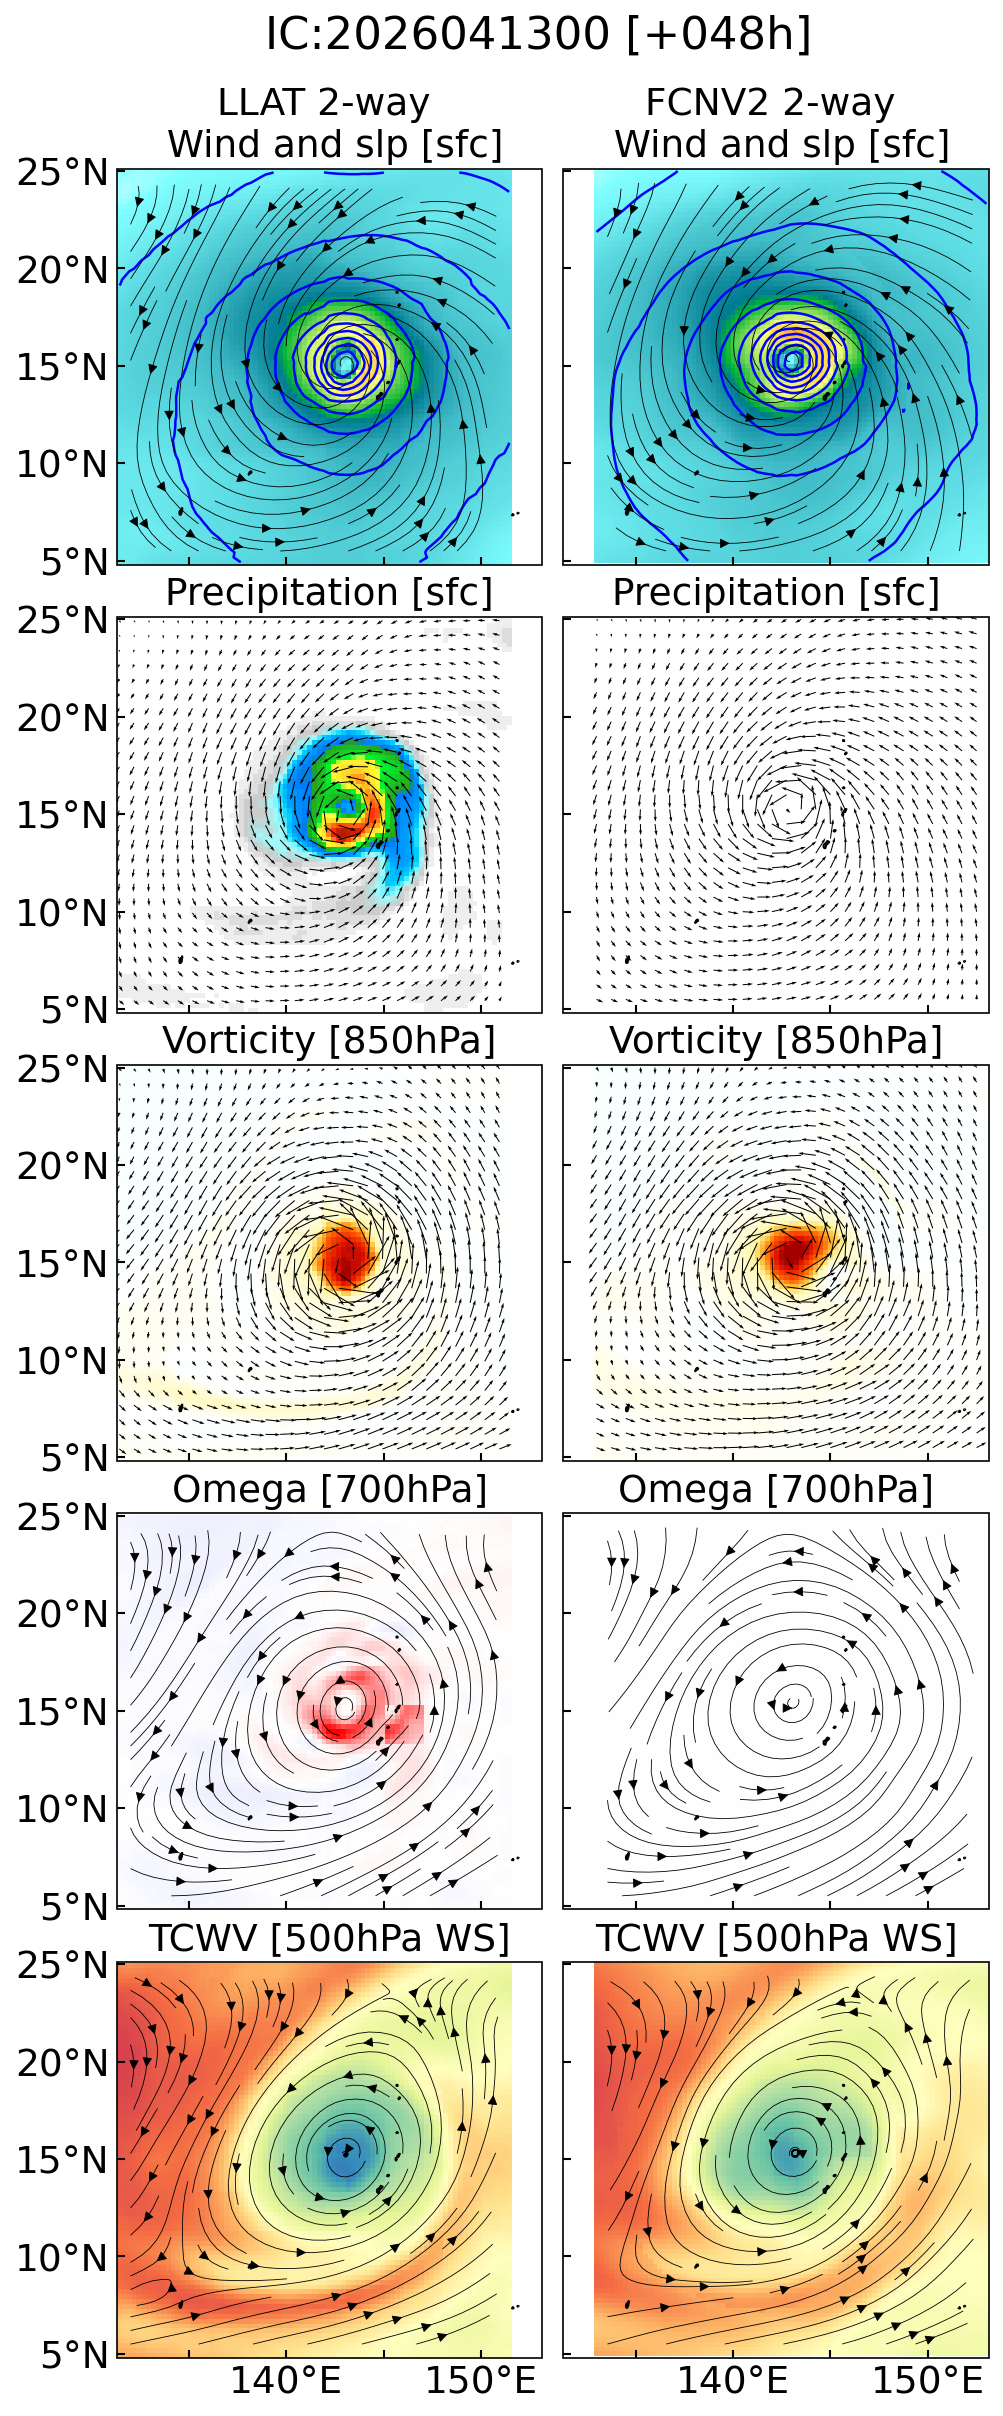

2026041300_048h


In [36]:
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes

import matplotlib.transforms as mtransforms
from matplotlib.ticker import FuncFormatter

def lat_formatter(x, pos):
    return f"{abs(int(x))}°{'N' if x >= 0 else 'S'}"

def lon_formatter(x, pos):
    return f"{abs(int(x))}°{'E' if x >= 0 else 'W'}"

# TC_ID = '202421W'
start_time = '2026041300'
model_datetime = datetime.datetime.strptime(start_time, "%Y%m%d%H")
sample_for_FCNV2 = '../input_data/LLAT_2026041300_input.nc'
experiments_path = {
    # "ERA5": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/ERA5/for_DLAMPty",
    "LLAT 2-way":f"../output_data/LLAT/",
    # "FCNV2 free":f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{model_datetime.strftime('%Y%m%d%H')}/FCNV2/forecast/"
    "FCNV2 2-way":f"../output_data/FCNV2/"
}
TC_track_FCNV2 = pd.read_csv("../output_data/FCNV2_TC_track_radius5.csv")
            
save_plot = 'plan_views'
os.makedirs(save_plot, exist_ok=True)
# setting for plot
info = {
        "model_title": "v57 5d (SG, ra)",
        "upper_vars": ['u', 'v', 't', 'q', 'z', 'w'],
        "upper_units": ["m/s", "m/s", "K", "kg kg**-1", "m**2 s**-2", "Pa s**-1"],
        "surface_vars": ['u10', 'v10', 't2m', 'd2m', 'msl', 'sp', 'tcwv', 'tp', 'mtnlwrf', 'sst_filled', 'f', 'solar', 'hgt', 'landmask', 'diurnal_sin', 'diurnal_cos', 'doy_sin', 'doy_cos'],
        "surface_units": ["m/s", "m/s", "K", "K", "Pa", "Pa", "kg m**-2", "m", 'W m**-2', 'K', '1/s', 'W m**-2', 'm', '1', '1', '1', '1', '1'],
        "pressure_levels" : [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
        'coastline_color': 'darkslategray',
    }

## for colorbar
quiver_skip = (slice(None, None, 3), slice(None, None, 3))
windspeed_cmap = make_cmap("clist_WS")
prec_cmap = make_cmap("clist_prec")
prec_cticks = prec_levels[::2]
prec_cticks.pop(1)
vort_cmap = make_cmap("clist_vort")

fore_i = 0
# for fore_i in range(30):
for fore_i in range(8,9):
    # for plot
    fig_col = 2
    # fig = plt.figure(figsize=(21, 8.5*2.5), dpi=150, layout="tight")
    # fig = plt.figure(figsize=(8*0.5*fig_col, 20), dpi=150, layout="tight")
    fig = plt.figure(figsize=(9*0.5*fig_col-1.5, 18.5), dpi=150, layout="tight")
    # plt.title(train_time_ID[i])
    font = {'size'       : 18
    }
    axes = {'titlesize'  : 18,
    'labelsize'  : 18,
    }
    mpl.rc('font', **font)  # pass in the font dict as kwargs
    mpl.rc('axes', **axes)

    gs = gridspec.GridSpec(5, fig_col, wspace=0.05, hspace=0.05)
    ax = None
    start_position = -1
    fig.suptitle(f'IC:{model_datetime.strftime("%Y%m%d%H")} [+{fore_i*6:0>3}h]', y=0.95)
    target_time = model_datetime + datetime.timedelta(hours=6*fore_i)
    for model_title, path in experiments_path.items():
        if model_title == "ERA5":
            data_path = f'{path}/{target_time.strftime("%Y%m%d%H")}_combined.nc'
            ERA5_data = xr.open_dataset(data_path)
            ERA5_data = ERA5_data.isel(latitude=np.arange(40,121), longitude=np.arange(40,121))
            ERA5_xr = calc_additional_vars(ERA5_data)
            ERA5_xr['streamplot_lon'] = ERA5_xr['longitude']
            ERA5_xr['streamplot_lat'] = ERA5_xr['latitude']
            data_xr = ERA5_xr.squeeze()
            start_position+=1
            position = start_position
            
        if model_title == "LLAT 2-way":        
            model_upper = np.load(os.path.join(path, f"output_upper_{fore_i*6:0>3}h.npy"))
            model_sfc   = np.load(os.path.join(path, f"output_sfc_{fore_i*6:0>3}h.npy"))
            model2_xr = to_xarray(model_upper, model_sfc, info['upper_vars'], info['surface_vars'], info['upper_units'], info['surface_units'], info['pressure_levels'])
            data_xr = model2_xr
            start_position+=1
            position = start_position
        if model_title[:5] == 'FCNV2':
            demo_ERA5_path = sample_for_FCNV2
            FCNV2_data = np.load(os.path.join(path, f"output_weather_{fore_i*6:0>3}h.npy"))
            FCNV2_TC_center_lon = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lon"]
            FCNV2_TC_center_lat = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lat"]
            lon_index = np.arange(np.int_((FCNV2_TC_center_lon-80)/0.25)-40,np.int_((FCNV2_TC_center_lon-80)/0.25)+41)
            lat_index = np.arange(np.int_((80-FCNV2_TC_center_lat)/0.25)-40,np.int_((80-FCNV2_TC_center_lat)/0.25)+41)
            FCNV2_data = FCNV2_data[:,lat_index,:][:,:,lon_index]
            FCNV2_lon =  np.arange(-40,41)*0.25+FCNV2_TC_center_lon
            FCNV2_lat =  np.flip(np.arange(-40,41))*0.25+FCNV2_TC_center_lat
            FCNV2_xr = xr.open_dataset(demo_ERA5_path)
            FCNV2_xr['u'].data = FCNV2_data[ 8:21, :, :][np.newaxis,...]
            FCNV2_xr['v'].data = FCNV2_data[21:34, :, :][np.newaxis,...]
            FCNV2_xr['t'].data = FCNV2_data[47:60, :, :][np.newaxis,...]
            FCNV2_xr['q'].data = np.zeros([1,13,81,81])
            FCNV2_xr['z'].data = FCNV2_data[34:47, :, :][np.newaxis,...]
            FCNV2_xr['w'].data = np.zeros([1,13,81,81])
            FCNV2_xr['u10'].data = FCNV2_data[0, :, :][np.newaxis,...]
            FCNV2_xr['v10'].data = FCNV2_data[1, :, :][np.newaxis,...]
            FCNV2_xr['t2m'].data = FCNV2_data[4, :, :][np.newaxis,...]
            FCNV2_xr['d2m'].data = np.zeros([1,81,81])
            FCNV2_xr['msl'].data = FCNV2_data[6, :, :][np.newaxis,...]
            FCNV2_xr['sp'].data = FCNV2_data[5, :, :][np.newaxis,...]
            FCNV2_xr['tcwv'].data = FCNV2_data[7, :, :][np.newaxis,...]
            FCNV2_xr['tp'].data = np.zeros([1,81,81])
            FCNV2_xr['mtnlwrf'].data = np.zeros([1,81,81])
            FCNV2_xr['sst'].data = np.zeros([1,81,81])
            FCNV2_xr = FCNV2_xr.assign_coords({
                "latitude": FCNV2_lat,
                "longitude": FCNV2_lon,
            })
            FCNV2_xr = calc_additional_vars(FCNV2_xr)
            FCNV2_xr['streamplot_lon'] = FCNV2_xr['longitude']
            FCNV2_xr['streamplot_lat'] = FCNV2_xr['latitude']
            data_xr = FCNV2_xr.squeeze()
            start_position+=1
            position = start_position

        ################# model plot #################
        X, Y = np.meshgrid(data_xr.longitude, data_xr.latitude)
        ###########  slp(msl)  ###########
        ax = fig.add_subplot(gs[position],sharex=ax,sharey=ax, projection=ccrs.PlateCarree())
        
        ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        # ax = fig.add_subplot(2, 5, position, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore
        ax.set_title(f"{model_title} \n Wind and slp [sfc]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.ws10), cmap=windspeed_cmap, vmin=0, vmax=40
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")
            
        ax.contour(
            data_xr.longitude, data_xr.latitude,
            (np.squeeze(data_xr.msl) / 100), levels=np.arange(900, 1033, 4)
            , colors="b", linewidths=1.2
        )
        # ax.set_xlim([lon_min,lon_max])
        # ax.set_ylim([lat_min,lat_max])
        ax.streamplot(
            X, Y,
            data_xr.u10,
            data_xr.v10,
            color="k",
            linewidth=0.4,
        )
        # ax.set_title(f"{model_title} Wind and slp [sfc]")

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in')
        else:
            ax.tick_params(labelleft=False, direction='in') 
        
        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)
        
        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0+0.014,
            axpos.x1+0.025,
            axpos.y1+0.02
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="max")
            cbar.ax.tick_params(labelsize=14,direction='in')
        
        ###########  precp.(tp)  ###########
        position += fig_col
        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        ax.set_title(f"Precipitation [sfc]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.tp)*1000, cmap=prec_cmap, vmin=0, vmax=20
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")
            
        ax.quiver(
            data_xr.longitude[quiver_skip[0]], data_xr.latitude[quiver_skip[1]],
            np.squeeze(data_xr.u10)[quiver_skip],
            np.squeeze(data_xr.v10)[quiver_skip],
            color="k",
            linewidth=0.4,
            scale=400
        )
        # ax.set_title(f"{model_title} Wind and precp. [sfc]")
        

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)

        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)
        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0+0.0085,
            axpos.x1+0.025,
            axpos.y1+0.014
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="max", ticks=prec_cticks)
            cbar.ax.tick_params(labelsize=14,direction='in')
        
        ###########  850hpa vorticity(vort)  ###########
        position += fig_col
        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        ax.set_title(f"Vorticity [850hPa]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            (1e5*np.squeeze(data_xr.vort.sel(level=850))),
            cmap=vort_cmap, vmin=-65, vmax=65
        )
        divider = make_axes_locatable(ax)
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")

        ax.quiver(
            data_xr.longitude[quiver_skip[0]], data_xr.latitude[quiver_skip[1]],
            np.squeeze(data_xr.u.sel(level=850))[quiver_skip],
            np.squeeze(data_xr.v.sel(level=850))[quiver_skip],
            color="k",
            linewidth=0.4,
            scale=400
        )
        # ax.set_xlim(data_xr.longitude.min(), data_xr.longitude.max())
        # ax.set_ylim(data_xr.latitude.min(), data_xr.latitude.max())
        # ax.set_title(f"{model_title} Wind and Vort. [850hpa]")

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)

        
        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)
        
        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0+0.003,
            axpos.x1+0.025,
            axpos.y1+0.0077
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="both")
            cbar.ax.tick_params(labelsize=14,direction='in')
        
        ###########  omega  ###########
        position += fig_col
        
        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        ax.set_title(f"Omega [700hPa]", fontsize=18)
        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.w.sel(level=700)), cmap="bwr_r", vmin=-2.5, vmax=2.5
        )
        divider = make_axes_locatable(ax)  
        # if np.mod(position, fig_col)==0:
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")

        ax.streamplot(
            X, Y,
            data_xr.u.sel(level=700),
            data_xr.v.sel(level=700),
            color="k",
            linewidth=0.4,
        )
        # ax.set_title(f"{model_title} Wind and ω [700hPa]")

        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)
            # ax.set_yticklabels([]) 
        
        ax.set_xticks(np.arange(90, 161, 5))
        ax.tick_params(labelbottom=False, direction='in', width=1.0, length=4)
        # ax.set_xticklabels([]) 
        
        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0-0.004,
            axpos.x1+0.025,
            axpos.y1+0.002
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="both")
            cbar.ax.tick_params(labelsize=14,direction='in')
        # cbar.set_ticks(np.arange(200,301,20))
        
        ###########  tcwv  ###########
        position += fig_col
        
        ax = fig.add_subplot(gs[position], sharex=ax, sharey=ax, projection=ccrs.PlateCarree())
        ax.coastlines() # type: ignore

        a0 = ax.pcolormesh(
            data_xr.longitude, data_xr.latitude,
            np.squeeze(data_xr.tcwv), cmap="Spectral", vmin=15, vmax=85
        )
        
        ax.set_title(f"TCWV [500hPa WS]", fontsize=18)
        ax.streamplot(
            X, Y,
            data_xr.u.sel(level=500),
            data_xr.v.sel(level=500),
            color="k",
            linewidth=0.4,
        )    
        ax.set_yticks(np.arange(5, 61, 5))
        if np.mod(position, fig_col)==0:
            ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        else:
            ax.tick_params(labelleft=False, direction='in', width=1.0, length=4)
            # ax.set_yticklabels([]) 
        ax.set_xticks(np.arange(90, 161, 5))
        xticks = ax.get_xticks()
        ax.tick_params(labelbottom=True, direction='in', width=1.0, length=4)
        ax.set_xticklabels([f"{abs(int(t))}°{'E' if t >= 0 else 'W'}" if i % 2 == 0 else "" for i, t in enumerate(xticks)])

        divider = make_axes_locatable(ax)
        #     cax = divider.append_axes("right", size="5%", pad=0.2, axes_class=maxes.Axes)
        #     plt.colorbar(a0, cax=cax, extend="both")


        if np.mod(position, fig_col)==2:
            axpos = ax.get_position()
            caxpos = mtransforms.Bbox.from_extents(
            axpos.x1+0.01,
            axpos.y0-0.010,
            axpos.x1+0.025,
            axpos.y1-0.0035
            )
            cax = ax.figure.add_axes(caxpos)
            cbar = plt.colorbar(a0,cax=cax, extendfrac=0.07, extend="both")  
            cbar.ax.tick_params(labelsize=14,direction='in')
            
        # ax.set_title(f"{model_title} Wind [500hPa] and tcwv")
    plt.subplots_adjust(left=0.125,
            bottom=0.1, 
            right=0.9, 
            top=0.9, 
            wspace=0.05, 
            hspace=0.05)
    plt.savefig(f'{save_plot}/{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h',dpi=200)
    plt.show()
    plt.close()
    print(f'{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h')

/home/yungyun/.local/lib/python3.11/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/home/yungyun/.local/lib/python3.11/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/home/yungyun/.local/lib/python3.11/site-packages/metpy/calc/thermo.py:1754: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)
/home/yungyun/.local/lib/python3.11/site-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/home/yungyun/.local/lib/python3.11/site-packages/pysolar/numeric.py:62: UserWarning: no explicit representation of timezones available for np.datetime64
  dd = numpy.array(d, dtype='datetime64[D]')
/home/yungyun/.local/lib/

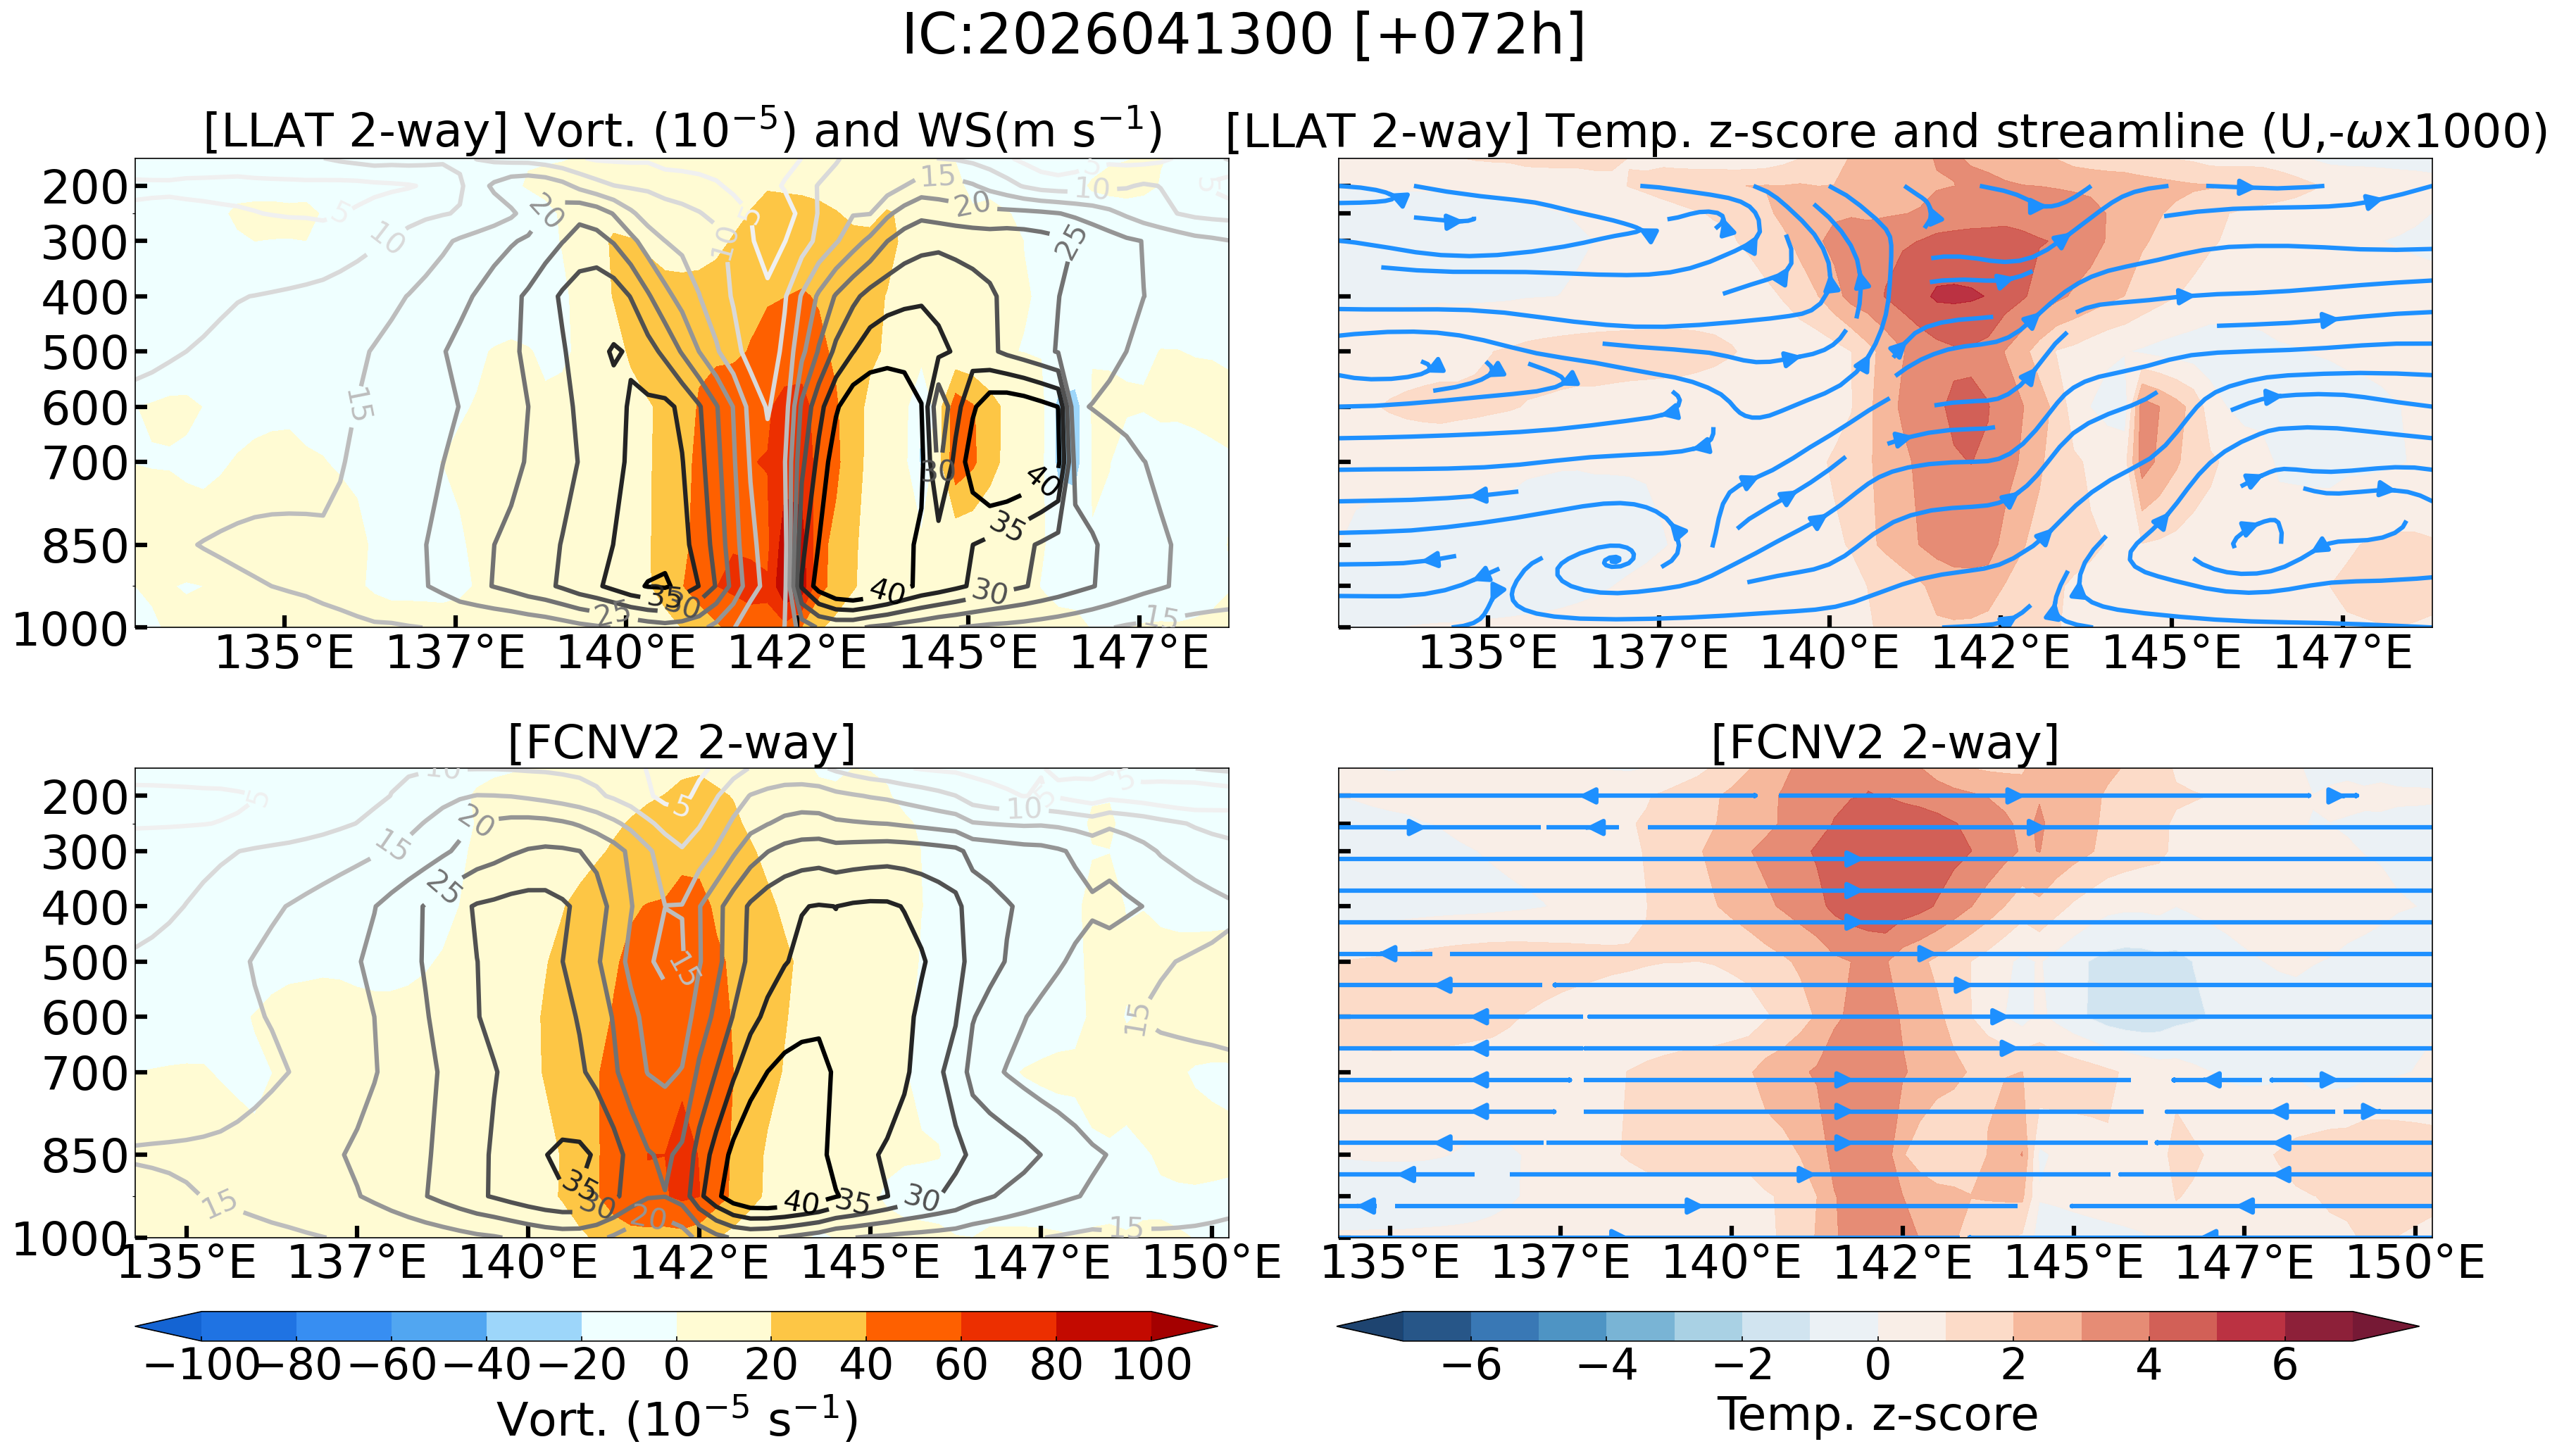

2026041300_072h


In [35]:
# import cartopy.crs as ccrs
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# import matplotlib.axes as maxes

# import matplotlib.transforms as mtransforms
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import LogFormatter

def lat_formatter(x, pos):
    return f"{abs(int(x))}°{'N' if x >= 0 else 'S'}"

def lon_formatter(x, pos):
    return f"{abs(int(x))}°{'E' if x >= 0 else 'W'}"


start_time = '2026041300'
model_datetime = datetime.datetime.strptime(start_time, "%Y%m%d%H")
sample_for_FCNV2 = '../input_data/LLAT_2026041300_input.nc'
experiments_path = {
    # "ERA5": f"/wk2/yungyun/FCNV2_TC/{TC_ID}/ERA5/for_DLAMPty",
    "LLAT 2-way":f"../output_data/LLAT/",
    # "FCNV2 free":f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{model_datetime.strftime('%Y%m%d%H')}/FCNV2/forecast/"
    "FCNV2 2-way":f"../output_data/FCNV2/"
}
TC_track_FCNV2 = pd.read_csv("../output_data/FCNV2_TC_track_radius5.csv")
            
save_plot = 'cross_sections'
os.makedirs(save_plot, exist_ok=True)
# setting for plot
info = {
        "model_title": "v57 5d (SG, ra)",
        "upper_vars": ['u', 'v', 't', 'q', 'z', 'w'],
        "upper_units": ["m/s", "m/s", "K", "kg kg**-1", "m**2 s**-2", "Pa s**-1"],
        "surface_vars": ['u10', 'v10', 't2m', 'd2m', 'msl', 'sp', 'tcwv', 'tp', 'mtnlwrf', 'sst_filled', 'f', 'solar', 'hgt', 'landmask', 'diurnal_sin', 'diurnal_cos', 'doy_sin', 'doy_cos'],
        "surface_units": ["m/s", "m/s", "K", "K", "Pa", "Pa", "kg m**-2", "m", 'W m**-2', 'K', '1/s', 'W m**-2', 'm', '1', '1', '1', '1', '1'],
        "pressure_levels" : [50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
        'coastline_color': 'darkslategray',
    }

## for colorbar
windspeed_cmap = make_cmap("clist_WS")
vort_cmap = make_cmap("clist_vort")
omage_inflation = 1000
# for fore_i in range(20,21):
for fore_i in range(12,13):
# for fore_i in range(31):
    # for plot
    fig_col = len(experiments_path); position = 0 
    levels_ticks = [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100, 50]
    # fig = plt.figure(figsize=(40,20), dpi=150)
    fig = plt.figure(figsize=(25,18/3*fig_col+2), dpi=150)
    font = {'size'       : 32
    }
    axes = {'titlesize'  : 32,
    'labelsize'  : 32,
    }
    mpl.rc('font', **font)  # pass in the font dict as kwargs
    mpl.rc('axes', **axes)
    # gs = gridspec.GridSpec(fig_col, 3, width_ratios=[2, 2, 2], height_ratios=[1.2, 1.2, 1.2], wspace=0.1, hspace=0.3)
    # gs = gridspec.GridSpec(fig_col, 2, width_ratios=[2, 2], height_ratios=[1.2,1.2, 1.2, 1.2, 1.2], wspace=0.1, hspace=0.3)
    gs = gridspec.GridSpec(fig_col, 2, width_ratios=[2, 2], height_ratios=(np.ones(fig_col)*1.2).tolist(), wspace=0.1, hspace=0.3,top=0.88)
    ax = None
    fig.suptitle(f'IC:{model_datetime.strftime("%Y%m%d%H")} [+{fore_i*6:0>3}h]', y=0.98)
    target_time = model_datetime + datetime.timedelta(hours=6*fore_i)
    for model_title, path in experiments_path.items():
        if model_title == "ERA5":
            data_path = f'{path}/{target_time.strftime("%Y%m%d%H")}_combined.nc'
            ERA5_data = xr.open_dataset(data_path)
            ERA5_data = ERA5_data.isel(latitude=np.arange(40,121), longitude=np.arange(40,121))
            ERA5_xr = calc_additional_vars(ERA5_data)
            ERA5_xr['streamplot_lon'] = ERA5_xr['longitude']
            ERA5_xr['streamplot_lat'] = ERA5_xr['latitude']
            data_xr = ERA5_xr.squeeze()
            # position = 0
            
        if model_title[:4] == "LLAT":        
            model_upper = np.load(os.path.join(path, f"output_upper_{fore_i*6:0>3}h.npy"))
            model_sfc   = np.load(os.path.join(path, f"output_sfc_{fore_i*6:0>3}h.npy"))
            model2_xr = to_xarray(model_upper, model_sfc, info['upper_vars'], info['surface_vars'], info['upper_units'], info['surface_units'], info['pressure_levels'])
            data_xr = model2_xr
            # position = 1\
        # if model_title[:4] == "DLDA" and "original" in model_title:      
        # if model_title == 'FCNV2 free': 
        if model_title[:5] == 'FCNV2':
            demo_ERA5_path = sample_for_FCNV2
            # TC_track_FCNV2 = pd.read_csv(f"/wk2/yungyun/FCNV2_TC/{TC_ID}/one_way_couple_model/start_from_{model_datetime.strftime('%Y%m%d%H')}/FCNV2_TC_track_radius5.csv")
            FCNV2_data = np.load(os.path.join(path, f"output_weather_{fore_i*6:0>3}h.npy"))
            FCNV2_TC_center_lon = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lon"]
            FCNV2_TC_center_lat = TC_track_FCNV2[TC_track_FCNV2["time"] == np.int_(target_time.strftime("%Y%m%d%H"))].iloc[0]["lat"]
            lon_index = np.arange(np.int_((FCNV2_TC_center_lon-80)/0.25)-40,np.int_((FCNV2_TC_center_lon-80)/0.25)+41)
            lat_index = np.arange(np.int_((80-FCNV2_TC_center_lat)/0.25)-40,np.int_((80-FCNV2_TC_center_lat)/0.25)+41)
            FCNV2_data = FCNV2_data[:,lat_index,:][:,:,lon_index]
            FCNV2_lon =  np.arange(-40,41)*0.25+FCNV2_TC_center_lon
            FCNV2_lat =  np.flip(np.arange(-40,41))*0.25+FCNV2_TC_center_lat
            FCNV2_xr = xr.open_dataset(demo_ERA5_path)
            FCNV2_xr['u'].data = FCNV2_data[ 8:21, :, :][np.newaxis,...]
            FCNV2_xr['v'].data = FCNV2_data[21:34, :, :][np.newaxis,...]
            FCNV2_xr['t'].data = FCNV2_data[47:60, :, :][np.newaxis,...]
            FCNV2_xr['q'].data = np.zeros([1,13,81,81])
            FCNV2_xr['z'].data = FCNV2_data[34:47, :, :][np.newaxis,...]
            FCNV2_xr['w'].data = np.zeros([1,13,81,81])
            FCNV2_xr['u10'].data = FCNV2_data[0, :, :][np.newaxis,...]
            FCNV2_xr['v10'].data = FCNV2_data[1, :, :][np.newaxis,...]
            FCNV2_xr['t2m'].data = FCNV2_data[4, :, :][np.newaxis,...]
            FCNV2_xr['d2m'].data = np.zeros([1,81,81])
            FCNV2_xr['msl'].data = FCNV2_data[6, :, :][np.newaxis,...]
            FCNV2_xr['sp'].data = FCNV2_data[5, :, :][np.newaxis,...]
            FCNV2_xr['tcwv'].data = FCNV2_data[7, :, :][np.newaxis,...]
            FCNV2_xr['tp'].data = np.zeros([1,81,81])
            FCNV2_xr['mtnlwrf'].data = np.zeros([1,81,81])
            FCNV2_xr['sst'].data = np.zeros([1,81,81])
            FCNV2_xr = FCNV2_xr.assign_coords({
                "latitude": FCNV2_lat,
                "longitude": FCNV2_lon,
            })
            FCNV2_xr = calc_additional_vars(FCNV2_xr)
            FCNV2_xr['streamplot_lon'] = FCNV2_xr['longitude']
            FCNV2_xr['streamplot_lat'] = FCNV2_xr['latitude']
            data_xr = FCNV2_xr.squeeze()
            # position = 2
        xx,yy = np.meshgrid(data_xr['longitude'][8:-8],data_xr['level'][2:])    
        # ax = fig.add_subplot(gs[position])        
        # ax.set_title(f'[{model_title}] WS'+'(m s$^{-1}$)')
        # ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        # # ax.yaxis.set_major_formatter(FuncFormatter(level_formatter))
        # wind_lev = np.linspace(0,40,21)
        # a0 = ax.contourf(xx,yy,data_xr['ws'][2:,41,8:-8], levels=wind_lev,cmap=windspeed_cmap,extend='both')
        # ax.set_yscale('log')
        # ax.invert_yaxis()
        # ax.set_yticks(data_xr['level'][3:])
        # ax.get_yaxis().set_major_formatter(LogFormatter(labelOnlyBase=False))
        # ax.tick_params(labelleft=True, direction='in', width=3.0, length=8)
        # # cbar = plt.colorbar(a0,ax=ax, extendfrac=0.07, extend="both")  
        # # cbar.ax.tick_params(labelsize=20,direction='in')
        # # cbar.set_ticks([0, 10, 20, 30 , 40])
        # position+=1

        ax = fig.add_subplot(gs[position])             
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
        if position==0:
            ax.set_title(f'[{model_title}] Vort. '+'($10^{-5}$)'+' and WS'+'(m s$^{-1}$)')   
        else:
            ax.set_title(f'[{model_title}]')   
        vort_lev = np.linspace(-100,100,11)
        a1 = ax.contourf(xx,yy,data_xr['vort'][2:,41,8:-8]*1e5,levels=vort_lev,cmap=vort_cmap, extend='both')
        wind_lev = np.linspace(0,40,9)
        a0 = ax.contour(xx,yy,data_xr['ws'][2:,41,8:-8], levels=wind_lev, cmap='Greys', linewidths=3.0)
        ax.clabel(a0, fontsize=20)
        # ax.set_yscale('log')
        ax.set_ylim([150,1000])
        ax.invert_yaxis()
        # ax.set_yticks(data_xr['level'][3:])
        ax.get_yaxis().set_major_locator(mpl.ticker.FixedLocator(data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True).where(data_xr['level'][3:] != 250, drop=True)))
        # ax.get_yaxis().set_major_formatter(LogFormatter(labelOnlyBase=False))
        ax.get_yaxis().set_minor_locator(mpl.ticker.FixedLocator(data_xr['level'][3:]))
        ax.get_yaxis().set_minor_formatter(mpl.ticker.NullFormatter())  # 不顯示數字
        # ax.set_yticks(data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True).where(data_xr['level'][3:] != 250, drop=True))
        ax.tick_params(labelleft=True, direction='in', width=3.0, length=8)
        # cbar = plt.colorbar(a1,ax=ax, extendfrac=0.07, extend="both")
        # cbar.set_ticks([-100, -80, -60, -40, -20, 0, 20 , 40, 60, 80, 100])
        # cbar.ax.tick_params(labelsize=20,direction='in')
        position+=1

        # temp_ana = data_xr['t'] - np.mean(np.mean(data_xr['t'],axis=2),axis=1)
        # ax = fig.add_subplot(gs[position])             
        # ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))   
        # ax.set_title(f'[{model_title}] Temp. anomaly')   
        # temp_ana_lev = np.linspace(-15,15,31)
        # a2 = ax.contourf(xx,yy,temp_ana[:,41,:],levels=temp_ana_lev,cmap='RdBu_r', extend='both',alpha=0.9)
        # ax.set_yscale('log')
        # ax.invert_yaxis()
        # ax.set_yticks(levels_ticks,levels_ticks, fontsize=14) 
        # ax.tick_params(labelleft=True, direction='in', width=1.0, length=4)
        # cbar = plt.colorbar(a2,ax=ax, extendfrac=0.07, extend="both")
        # cbar.set_ticks([-15, -10, -5, 0, 5, 10, 15])
        # cbar.ax.tick_params(labelsize=14,direction='in')
        # position+=1
        
        temp_ana = data_xr['t'] - np.mean(np.mean(data_xr['t'],axis=2),axis=1)
        temp_zscore = temp_ana/data_xr['t'].std(dim=['latitude', 'longitude'])
        ax = fig.add_subplot(gs[position])             
        ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))   
        if position==1:
            ax.set_title(f'[{model_title}] Temp. z-score and streamline (U,-'+'$\omega$'+'x'+str(omage_inflation)+')')   
        else:
            ax.set_title(f'[{model_title}]')
        # ax.set_title(f'[{model_title}] Temp. z-score and streamline (U,-'+'$\omega$'+'x'+str(omage_inflation)+')')   
        temp_ana_lev = np.linspace(-7,7,15)
        a3 = ax.contourf(xx,yy,temp_zscore[2:,41,8:-8],levels=temp_ana_lev,cmap='RdBu_r', extend='both',alpha=0.9)
        new_level_streamline = np.linspace(200,1000, 17)
        new_data_for_streamline = data_xr.interp(level=new_level_streamline)
        new_xx,new_yy = np.meshgrid(data_xr['longitude'][8:-8],new_level_streamline)
        if  model_title!='FCNV2 free':
            a4 = ax.streamplot(new_xx, new_yy, new_data_for_streamline['u'][:,41,8:-8], new_data_for_streamline['w'][:,41,8:-8]*omage_inflation, color='dodgerblue',linewidth=3.0, density=[1, 0.5],arrowsize=2.2)
        # a4 = ax.barbs(xx, yy, data_xr['u'][2:,41,8:-8], data_xr['w'][2:,41,8:-8]*100)
        # ax.set_yscale('log')
        ax.set_ylim([1000,150])
        # ax.invert_yaxis()
        ax.set_yticks(data_xr['level'][3:])
        # ax.set_yticks((np.log(data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True)*100)),data_xr['level'][3:].where(data_xr['level'][3:] != 925, drop=True).values.tolist())
        # ax.get_yaxis().set_major_formatter(LogFormatter(labelOnlyBase=False))
        # ax.set_yticks(levels_ticks[:-3],levels_ticks[:-3])
        ax.tick_params(labelleft=False, direction='in', width=3.0, length=8)
        position+=1
    
    # 調整內距，預留底部空間放三個 colorbar
    fig.subplots_adjust(bottom=0.15, top=0.93, left=0.08, right=0.95, wspace=0.15)
    # cax = fig.add_axes([0.07, 0.12, 0.28, 0.025])
    # cbar = fig.colorbar(a0, cax=cax, orientation='horizontal',extendfrac=0.07, extend="both", label='WS (m s$^{-1}$)')
    # cbar.ax.tick_params(labelsize=32,direction='in')
    # cbar.set_ticks([0, 10, 20, 30 , 40])

    cax = fig.add_axes([0.08, 0.08, 0.41, 0.020])
    # cax = fig.add_axes([0.38, 0.12, 0.28, 0.025])
    cbar = fig.colorbar(a1, cax=cax, orientation='horizontal',extendfrac=0.07, extend="both", label='Vort. ($10^{-5}$ s$^{-1}$)')
    cbar.set_ticks([-100, -80, -60, -40, -20, 0, 20 , 40, 60, 80, 100])
    cbar.ax.tick_params(labelsize=30,direction='in')
    
    cax = fig.add_axes([0.535, 0.08, 0.41, 0.020])
    # cax = fig.add_axes([0.69, 0.12, 0.28, 0.025])
    cbar = fig.colorbar(a3,cax=cax, extendfrac=0.07, extend="both", orientation='horizontal',label='Temp. z-score')
    cbar.set_ticks([-6,-4,-2, 0, 2,  4,  6])
    cbar.ax.tick_params(labelsize=30,direction='in')
    # plt.savefig('test.png')
    plt.savefig(f'{save_plot}/{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h',dpi=200)
    plt.show()
    plt.close()
    print(f'{model_datetime.strftime("%Y%m%d%H")}_{np.int_(fore_i*6):0>3}h')
# ax1.contourf(lons, levels, ws_sec, levels=21)
# data_xr